# 📊 Customer Churn Prediction
## Algorithm: Logistic Regression

---

| Detail        | Info                                        |
|---------------|---------------------------------------------|
| **Author**    | D.N. Rajapaksha (Dumindu)                   |
| **Dataset**   | Telco Customer Churn — Kaggle               |
| **Algorithm** | Logistic Regression (Supervised Learning)   |
| **Task**      | Binary Classification (Churn: Yes / No)     |
| **Language**  | Python 3                                    |

> **Dataset Citation:** IBM Sample Data — Telco Customer Churn.  
> Available at: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

---

### Workflow
```
1. Import Libraries  →  2. Load Data  →  3. Preprocessing  →  4. Train/Test Split
         ↓
5. Train Model  →  6. Evaluate (Accuracy, Precision, Recall, F1)  →  7. Visualise Results
```

---
## Step 1 — Import Libraries

In [1]:
# ─────────────────────────────────────────────────────────────────
# SECTION 1: IMPORTS
# Purpose : Load all required libraries for data processing,
#           model training, and evaluation.
# ─────────────────────────────────────────────────────────────────

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# ── Plot style configuration ──────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi'     : 120,
    'axes.titlepad'  : 12,
    'axes.titlesize' : 13,
    'axes.titleweight': 'bold'
})

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


---
## Step 2 — Load Dataset

In [2]:
# ─────────────────────────────────────────────────────────────────
# SECTION 2: LOAD DATASET
# Source  : Telco Customer Churn — Kaggle (blastchar)
# Note    : Download CSV from Kaggle and place in the same folder,
#           OR update the path below.
# ─────────────────────────────────────────────────────────────────

# ── Option A: Load from local file (recommended after Kaggle download) ────
# df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# ── Option B: Load from public mirror URL ────────────────────────
DATA_URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/"
    "master/data/Telco-Customer-Churn.csv"
)

try:
    df = pd.read_csv(DATA_URL)
    print("✅ Dataset loaded from remote URL.")
except Exception as error:
    raise FileNotFoundError(
        "Remote load failed. Please download the dataset from:\n"
        "https://www.kaggle.com/datasets/blastchar/telco-customer-churn\n"
        f"Original error: {error}"
    )

# ── Quick overview ────────────────────────────────────────────────
print(f"\n📐 Shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"📋 Columns  : {df.columns.tolist()}")

df.head()

✅ Dataset loaded from remote URL.

📐 Shape    : 7,043 rows × 21 columns
📋 Columns  : ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---
## Step 3 — Preprocessing

Preprocessing pipeline:
1. Drop irrelevant column (`customerID`)
2. Fix data type issue in `TotalCharges`
3. Handle missing values
4. Encode categorical features
5. Encode target variable (`Churn`)
6. Scale numerical features (required for Logistic Regression)

In [3]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3.1: INITIAL INSPECTION
# ─────────────────────────────────────────────────────────────────

print("=" * 55)
print("  DATASET INSPECTION BEFORE PREPROCESSING")
print("=" * 55)

# Data types
print("\n📊 Data Types:")
print(df.dtypes)

# Missing values
print("\n🔍 Missing Values:")
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "  None found.")

# Target distribution
print("\n🎯 Target Variable (Churn) Distribution:")
print(df['Churn'].value_counts())
print(f"  Churn Rate: {(df['Churn'] == 'Yes').mean():.2%}")

  DATASET INSPECTION BEFORE PREPROCESSING

📊 Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

🔍 Missing Values:
  None found.

🎯 Target Variable (Churn) Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
  Churn Rate: 26.54%


In [4]:
# ─────────────────────────────────────────────────────────────────
# SECTION 3.2: PREPROCESSING PIPELINE
# ─────────────────────────────────────────────────────────────────

# Work on a copy — never mutate the raw dataframe
data = df.copy()

# ── Step 1: Drop customerID (identifier — not a feature) ─────────
data.drop(columns=['customerID'], inplace=True)
print("✅ Step 1 — Dropped 'customerID' column.")


# ── Step 2: Fix TotalCharges dtype (stored as string in raw data) ─
# Spaces exist where tenure == 0 → convert and fill with 0
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data['TotalCharges'].fillna(0.0, inplace=True)
print(f"✅ Step 2 — Fixed 'TotalCharges' dtype. "
      f"({df['TotalCharges'].dtype} → {data['TotalCharges'].dtype})")


# ── Step 3: Handle missing values ────────────────────────────────
remaining_nulls = data.isnull().sum().sum()
print(f"✅ Step 3 — Missing values remaining: {remaining_nulls}")


# ── Step 4: Encode TARGET variable ───────────────────────────────
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})
print(f"✅ Step 4 — Encoded target: Yes → 1, No → 0")
print(f"   Churn value counts: {data['Churn'].value_counts().to_dict()}")


# ── Step 5: Encode CATEGORICAL features ─────────────────────────
categorical_columns = data.select_dtypes(include=['object']).columns.tolist()
print(f"\n✅ Step 5 — Encoding {len(categorical_columns)} categorical columns...")

label_encoder = LabelEncoder()
binary_cols   = []   # columns with exactly 2 unique values → Label Encode
multi_cols    = []   # columns with 3+ unique values → One-Hot Encode

for col in categorical_columns:
    n_unique = data[col].nunique()
    if n_unique <= 2:
        data[col] = label_encoder.fit_transform(data[col].astype(str))
        binary_cols.append(col)
    else:
        multi_cols.append(col)

# One-hot encode multi-class columns (drop_first avoids dummy variable trap)
if multi_cols:
    data = pd.get_dummies(data, columns=multi_cols, drop_first=True)

print(f"   Label encoded  ({len(binary_cols)}) : {binary_cols}")
print(f"   One-hot encoded ({len(multi_cols)}) : {multi_cols}")
print(f"\n📐 Shape after encoding: {data.shape}")

✅ Step 1 — Dropped 'customerID' column.
✅ Step 2 — Fixed 'TotalCharges' dtype. (object → float64)
✅ Step 3 — Missing values remaining: 0
✅ Step 4 — Encoded target: Yes → 1, No → 0
   Churn value counts: {0: 5174, 1: 1869}

✅ Step 5 — Encoding 15 categorical columns...
   Label encoded  (5) : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
   One-hot encoded (10) : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

📐 Shape after encoding: (7043, 31)


---
## Step 4 — Train / Test Split

In [5]:
# ─────────────────────────────────────────────────────────────────
# SECTION 4: TRAIN / TEST SPLIT
# Strategy : 80% train | 20% test
#            stratify=y → preserves class ratio in both splits
#            random_state=42 → reproducibility
# ─────────────────────────────────────────────────────────────────

# ── Separate features (X) and target (y) ─────────────────────────
X = data.drop(columns=['Churn'])
y = data['Churn']

print(f"Feature matrix X : {X.shape}  ({X.shape[1]} features)")
print(f"Target vector  y : {y.shape}")
print(f"Overall churn rate: {y.mean():.2%}")

# ── Split ────────────────────────────────────────────────────────
TEST_SIZE    = 0.20
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y        # ensures balanced class split
)

print("\n" + "=" * 50)
print("  TRAIN / TEST SPLIT SUMMARY")
print("=" * 50)
print(f"  Training samples : {len(X_train):,}  ({len(X_train)/len(X):.0%})")
print(f"  Test samples     : {len(X_test):,}   ({len(X_test)/len(X):.0%})")
print(f"  Train churn rate : {y_train.mean():.2%}")
print(f"  Test  churn rate : {y_test.mean():.2%}")
print("=" * 50)

# ── Feature Scaling ───────────────────────────────────────────────
# Logistic Regression converges faster and performs better with scaled features.
# IMPORTANT: fit scaler on TRAINING data only to prevent data leakage.
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)        # transform only on test

print("\n✅ Features scaled (StandardScaler — zero mean, unit variance).")
print("   Note: Scaler fitted on training data only (prevents data leakage).")

Feature matrix X : (7043, 30)  (30 features)
Target vector  y : (7043,)
Overall churn rate: 26.54%

  TRAIN / TEST SPLIT SUMMARY
  Training samples : 5,634  (80%)
  Test samples     : 1,409   (20%)
  Train churn rate : 26.54%
  Test  churn rate : 26.54%

✅ Features scaled (StandardScaler — zero mean, unit variance).
   Note: Scaler fitted on training data only (prevents data leakage).


---
## Step 5 — Train the Model

**Logistic Regression** models the probability that a customer will churn using the **sigmoid function**:

$$P(\text{Churn}=1 \mid \mathbf{x}) = \frac{1}{1 + e^{-(\beta_0 + \boldsymbol{\beta}^T \mathbf{x})}}$$

- If the predicted probability **≥ 0.5** → predict **Churn = 1** (customer leaves)
- If the predicted probability **< 0.5** → predict **Churn = 0** (customer stays)

**Key Parameters used:**
- `C=1.0` — Regularisation strength (smaller = stronger regularisation)
- `penalty='l2'` — Ridge regularisation prevents overfitting
- `class_weight='balanced'` — Adjusts for class imbalance automatically
- `max_iter=1000` — Sufficient iterations to reach convergence

In [6]:
# ─────────────────────────────────────────────────────────────────
# SECTION 5: TRAIN LOGISTIC REGRESSION MODEL
# ─────────────────────────────────────────────────────────────────

# ── Instantiate model ────────────────────────────────────────────
model = LogisticRegression(
    penalty      = 'l2',        # Ridge regularisation
    C            = 1.0,         # Inverse regularisation strength
    solver       = 'lbfgs',     # Efficient for binary classification
    max_iter     = 1000,        # Iterations for convergence
    class_weight = 'balanced',  # Handles class imbalance
    random_state = 42           # Reproducibility
)

# ── Train model on scaled training data ──────────────────────────
model.fit(X_train_scaled, y_train)

# ── Generate predictions on test set ─────────────────────────────
y_pred      = model.predict(X_test_scaled)           # class labels: 0 or 1
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]  # churn probability

print("✅ Logistic Regression model trained successfully.")
print(f"\n   Training samples used : {X_train_scaled.shape[0]:,}")
print(f"   Features used         : {X_train_scaled.shape[1]}")
print(f"   Iterations to converge: {model.n_iter_[0]}")

✅ Logistic Regression model trained successfully.

   Training samples used : 5,634
   Features used         : 30
   Iterations to converge: 34


---
## Step 6 — Evaluate the Model

### Metrics Explained

| Metric | Formula | What it tells us |
|--------|---------|------------------|
| **Accuracy** | (TP+TN) / Total | % of all correct predictions |
| **Precision** | TP / (TP+FP) | Of predicted churners, how many actually churned? |
| **Recall** | TP / (TP+FN) | Of actual churners, how many did we catch? |
| **F1-Score** | 2 × (P×R)/(P+R) | Harmonic mean — balances Precision and Recall |

> **For churn prediction, Recall is especially important** — missing a churner (FN) is more costly than a false alarm (FP).

In [23]:
# ─────────────────────────────────────────────────────────────────
# SECTION 6.1: COMPUTE EVALUATION METRICS
# ─────────────────────────────────────────────────────────────────

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

# ── Print formatted results table ────────────────────────────────
print("")
print("╔══════════════════════════════════════════════╗")
print("║    LOGISTIC REGRESSION — EVALUATION RESULTS  ║")
print("╠══════════════════════════════════════════════╣")
print(f"║  Accuracy        :  {accuracy:.4f}  ({accuracy*100:.2f}%)         ║")
print(f"║  Precision       :  {precision:.4f}                   ║")
print(f"║  Recall          :  {recall:.4f}                   ║")
print(f"║  F1-Score        :  {f1:.4f}                   ║")
print(f"║  ROC-AUC         :  {roc_auc:.4f}                   ║")
print("╚══════════════════════════════════════════════╝")


╔══════════════════════════════════════════════╗
║    LOGISTIC REGRESSION — EVALUATION RESULTS  ║
╠══════════════════════════════════════════════╣
║  Accuracy        :  0.7402  (74.02%)         ║
║  Precision       :  0.5069                   ║
║  Recall          :  0.7861                   ║
║  F1-Score        :  0.6164                   ║
║  ROC-AUC         :  0.8414                   ║
╚══════════════════════════════════════════════╝


In [8]:
# ─────────────────────────────────────────────────────────────────
# SECTION 6.2: CLASSIFICATION REPORT
# Full per-class breakdown of Precision, Recall, F1
# ─────────────────────────────────────────────────────────────────

print("\n📋 CLASSIFICATION REPORT")
print("─" * 55)
print(classification_report(
    y_test, y_pred,
    target_names=['No Churn (0)', 'Churn (1)']
))


📋 CLASSIFICATION REPORT
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

No Churn (0)       0.90      0.72      0.80      1035
   Churn (1)       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



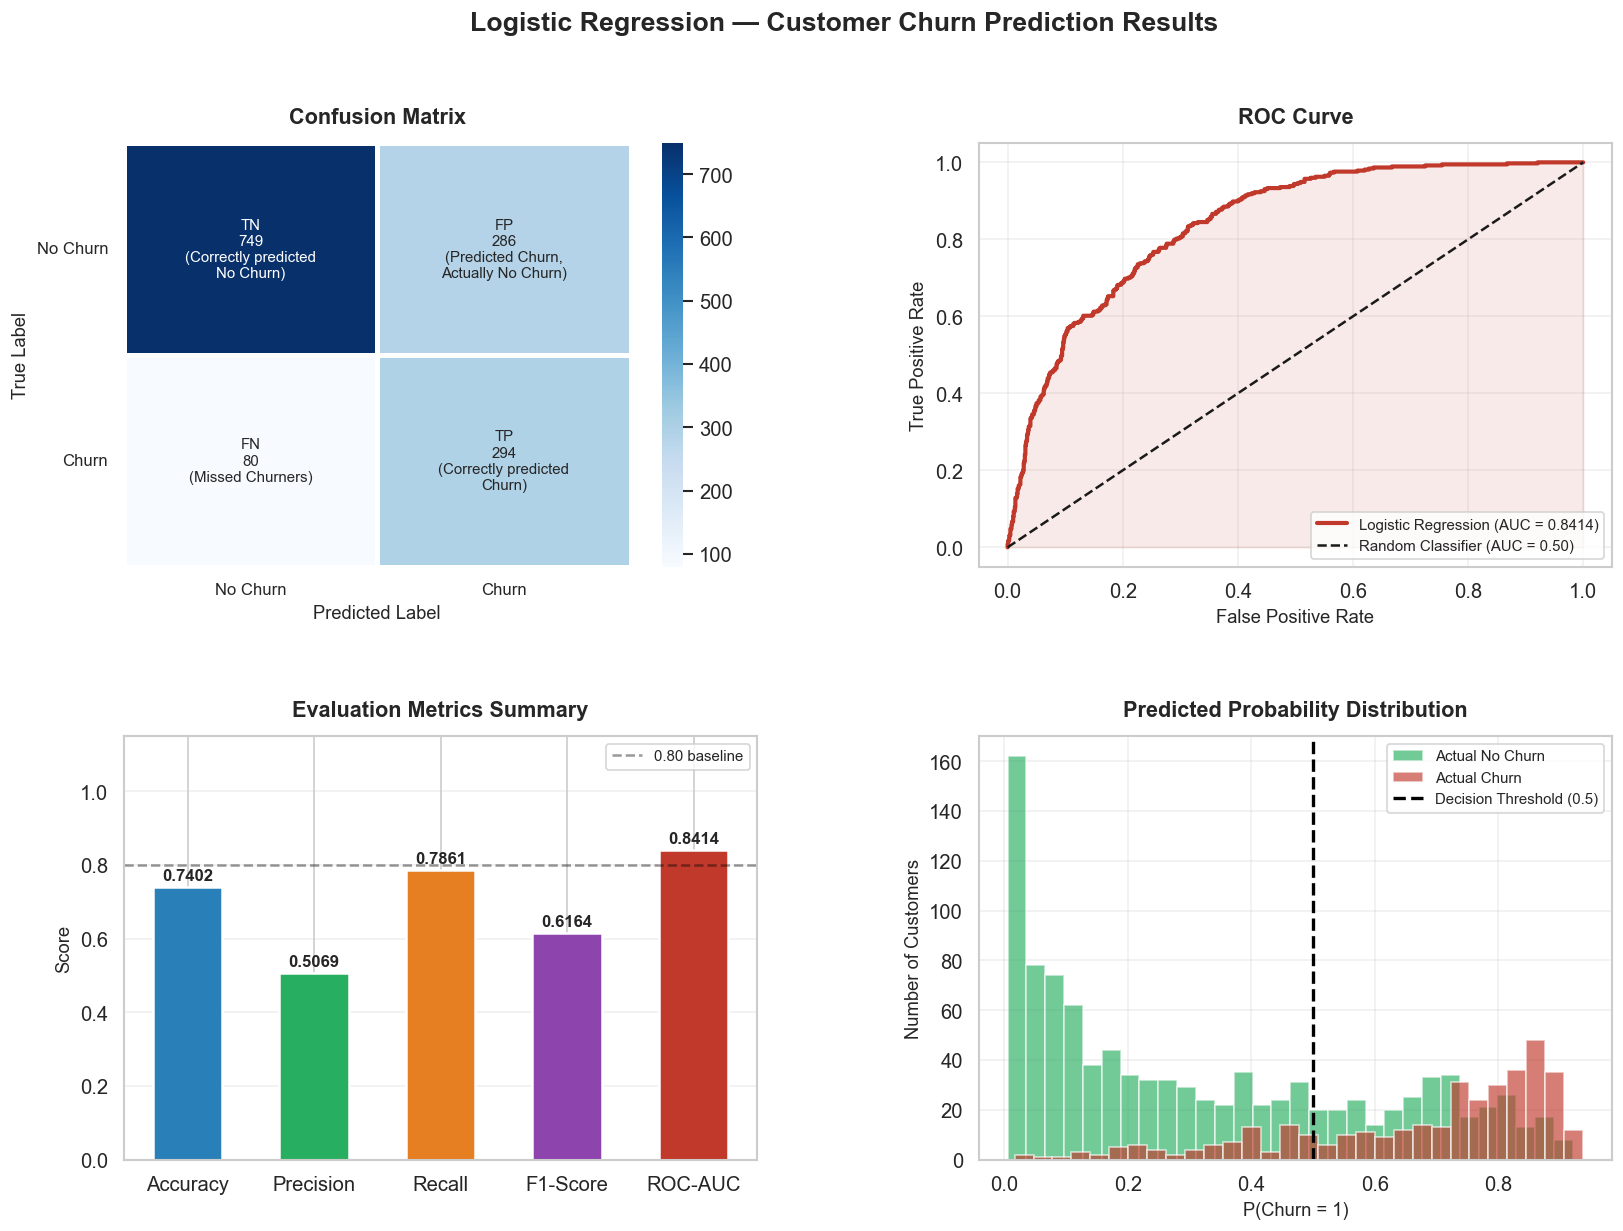


✅ Results dashboard saved as 'logistic_regression_results.png'


In [9]:
# ─────────────────────────────────────────────────────────────────
# SECTION 6.3: VISUALISE RESULTS — 4-Panel Dashboard
# Panels: Confusion Matrix | ROC Curve |
#         Metrics Bar Chart | Prediction Probability Distribution
# ─────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 11))
fig.suptitle(
    'Logistic Regression — Customer Churn Prediction Results',
    fontsize=16, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)

# ── Panel 1: Confusion Matrix ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

cm_labels = np.array([
    [f'TN\n{tn}\n(Correctly predicted\nNo Churn)',
     f'FP\n{fp}\n(Predicted Churn,\nActually No Churn)'],
    [f'FN\n{fn}\n(Missed Churners)',
     f'TP\n{tp}\n(Correctly predicted\nChurn)']
])

sns.heatmap(
    cm, annot=cm_labels, fmt='', cmap='Blues',
    ax=ax1, linewidths=2, linecolor='white',
    cbar=True, annot_kws={'size': 9}
)
ax1.set_title('Confusion Matrix')
ax1.set_xlabel('Predicted Label', fontsize=11)
ax1.set_ylabel('True Label', fontsize=11)
ax1.set_xticklabels(['No Churn', 'Churn'], fontsize=10)
ax1.set_yticklabels(['No Churn', 'Churn'], fontsize=10, rotation=0)


# ── Panel 2: ROC Curve ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

ax2.plot(
    fpr, tpr, color='#c0392b', lw=2.5,
    label=f'Logistic Regression (AUC = {roc_auc:.4f})'
)
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.50)')
ax2.fill_between(fpr, tpr, alpha=0.10, color='#c0392b')
ax2.set_title('ROC Curve')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(alpha=0.3)


# ── Panel 3: Metrics Bar Chart ────────────────────────────────────
ax3    = fig.add_subplot(gs[1, 0])
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metrics_values = [accuracy, precision, recall, f1, roc_auc]
bar_colors     = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad', '#c0392b']

bars = ax3.bar(
    metrics_names, metrics_values,
    color=bar_colors, edgecolor='white',
    width=0.55, linewidth=1.5
)

# Add value labels on bars
for bar, val in zip(bars, metrics_values):
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.4f}',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax3.set_ylim(0, 1.15)
ax3.set_title('Evaluation Metrics Summary')
ax3.set_ylabel('Score', fontsize=11)
ax3.axhline(y=0.80, color='black', linestyle='--', alpha=0.4, label='0.80 baseline')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)


# ── Panel 4: Predicted Probability Distribution ───────────────────
ax4 = fig.add_subplot(gs[1, 1])

churn_probs    = y_pred_prob[y_test == 1]
no_churn_probs = y_pred_prob[y_test == 0]

ax4.hist(
    no_churn_probs, bins=30, alpha=0.65,
    color='#27ae60', label='Actual No Churn', edgecolor='white'
)
ax4.hist(
    churn_probs, bins=30, alpha=0.65,
    color='#c0392b', label='Actual Churn', edgecolor='white'
)
ax4.axvline(
    x=0.5, color='black', linestyle='--',
    linewidth=2, label='Decision Threshold (0.5)'
)
ax4.set_title('Predicted Probability Distribution')
ax4.set_xlabel('P(Churn = 1)', fontsize=11)
ax4.set_ylabel('Number of Customers', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)


plt.savefig('logistic_regression_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Results dashboard saved as 'logistic_regression_results.png'")

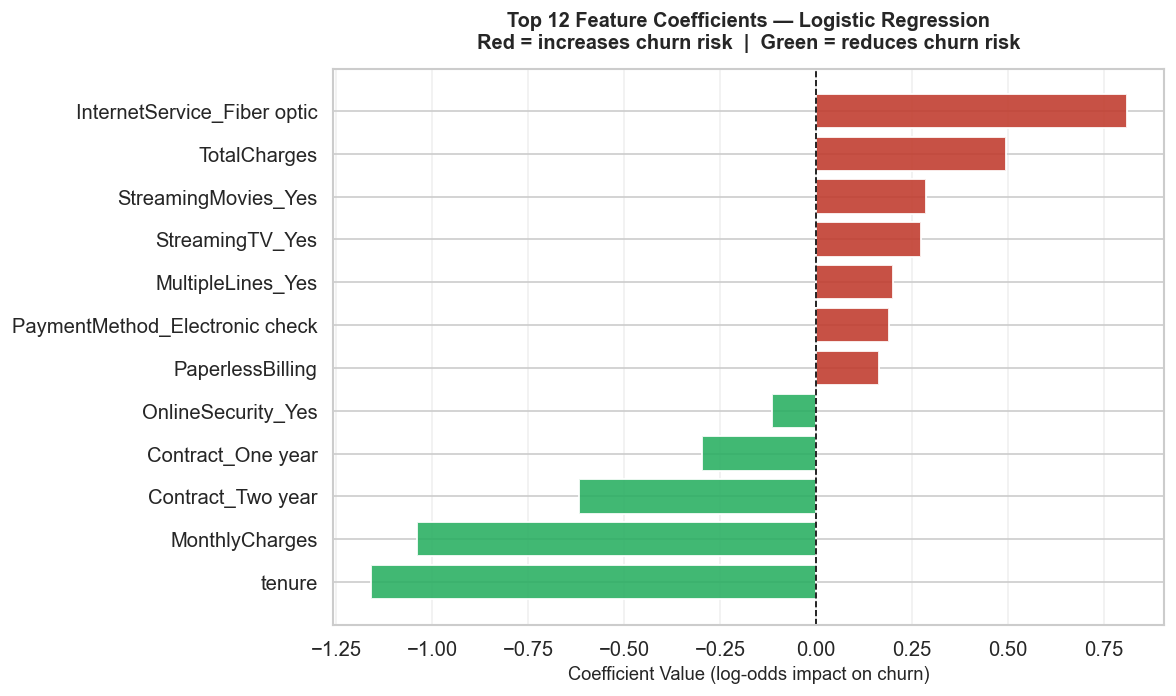

✅ Feature coefficients plot saved.


In [10]:
# ─────────────────────────────────────────────────────────────────
# SECTION 6.4: TOP FEATURE COEFFICIENTS
# Coefficients show which features drive churn predictions most.
# ─────────────────────────────────────────────────────────────────

TOP_N = 12

coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_[0]
}).reindex(pd.RangeIndex(len(X.columns)))

coef_df = (
    coef_df
    .assign(Abs_Coefficient=coef_df['Coefficient'].abs())
    .sort_values('Abs_Coefficient', ascending=False)
    .head(TOP_N)
    .sort_values('Coefficient')
)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#c0392b' if c > 0 else '#27ae60' for c in coef_df['Coefficient']]
ax.barh(
    coef_df['Feature'], coef_df['Coefficient'],
    color=colors, edgecolor='white', linewidth=1.2, alpha=0.88
)
ax.axvline(x=0, color='black', linewidth=1.0, linestyle='--')
ax.set_xlabel('Coefficient Value (log-odds impact on churn)', fontsize=11)
ax.set_title(
    f'Top {TOP_N} Feature Coefficients — Logistic Regression\n'
    'Red = increases churn risk  |  Green = reduces churn risk',
    fontsize=12, fontweight='bold'
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature coefficients plot saved.")

In [11]:
# ─────────────────────────────────────────────────────────────────
# SECTION 6.5: FINAL SUMMARY — FOR REPORT COMPARISON TABLE
# ─────────────────────────────────────────────────────────────────

results_summary = pd.DataFrame([{
    'Algorithm'  : 'Logistic Regression',
    'Accuracy'   : round(accuracy,  4),
    'Precision'  : round(precision, 4),
    'Recall'     : round(recall,    4),
    'F1-Score'   : round(f1,        4),
    'ROC-AUC'    : round(roc_auc,   4),
    'Train Size' : len(X_train),
    'Test Size'  : len(X_test)
}])

print("=" * 70)
print("  FINAL SUMMARY — Logistic Regression (D.N. Rajapaksha)")
print("=" * 70)
print(results_summary.to_string(index=False))
print("=" * 70)

# Save as CSV for team use
results_summary.to_csv('logistic_regression_metrics.csv', index=False)
print("\n✅ Results saved to 'logistic_regression_metrics.csv'")
print("\n✅ Notebook complete — D.N. Rajapaksha | Logistic Regression | Telco Churn")

  FINAL SUMMARY — Logistic Regression (D.N. Rajapaksha)
          Algorithm  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Size  Test Size
Logistic Regression    0.7402     0.5069  0.7861    0.6164   0.8414        5634       1409

✅ Results saved to 'logistic_regression_metrics.csv'
   Share this file with your teammates for the group comparison table.

✅ Notebook complete — D.N. Rajapaksha | Logistic Regression | Telco Churn
